In [3]:
# %matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import h5py

In [4]:
with h5py.File('/Users/albertxu/Downloads/episode000100/rawdata.h5') as f:
    gobs = f['gripper_obs']
    gdat = {k: np.array(gobs[k]) for k in gobs.keys()}

    robs = f['robot_obs']
    rdat = {k: np.array(robs[k]) for k in robs.keys()}

    cobs = f['camera_obs']
    cdat = {k: np.array(cobs[k]) for k in cobs.keys()}


In [5]:
def ewma(data, alpha=.05):
    acc = 0
    vals = []
    for di in data:
        acc = alpha * di + (1 - alpha) * acc
        vals.append(acc)

    return np.array(vals)

In [6]:
periods = [
    [823, 1300],
    [1450, 2000],
    [2100, 2600],
    [2640, 3000],
    [3050, 3400]
]

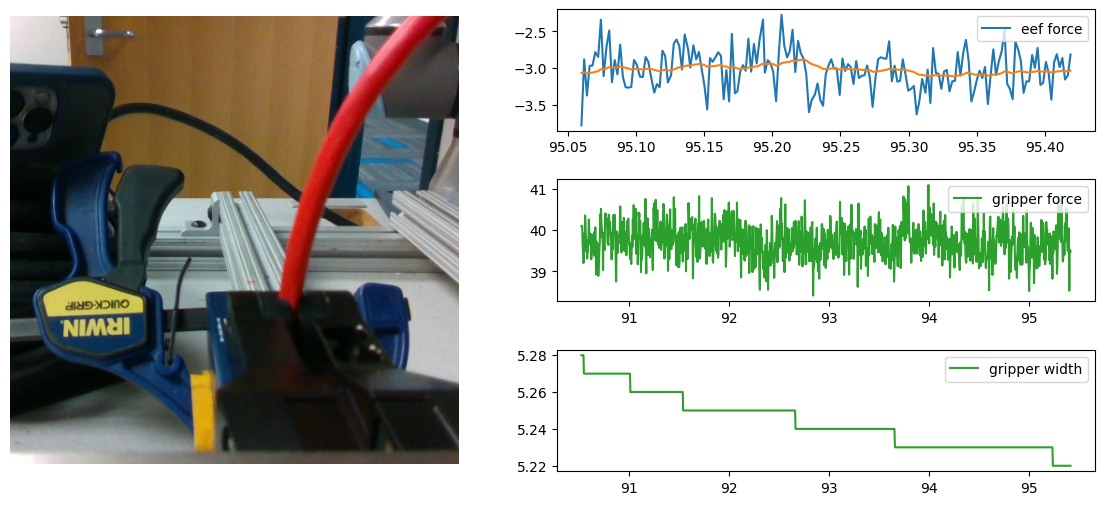

In [7]:
# Prototype figure
i = 2850
t = cdat['time'][i]

ri = np.abs(rdat['time'] - t).argmin()
gi = np.abs(gdat['time'] - t).argmin()

dt = 5
delt_r = int(dt / (rdat['time'][1] - rdat['time'][0]))
delt_g = int(dt / (gdat['time'][1] - gdat['time'][0]))
smoothed = ewma(rdat['actual_force'][:,2], alpha=.04)



fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1.2], hspace=0.4)

ax_img = fig.add_subplot(gs[:, 0])    # left: all 3 rows
ax1    = fig.add_subplot(gs[0, 1])    # right top
ax2    = fig.add_subplot(gs[1, 1])    # right middle
ax3    = fig.add_subplot(gs[2, 1])    # right bottom

ax_img.set_aspect('equal')
ax_img.axis('off')
ax_img.imshow(cdat['image_bgr'][i][:,:,::-1])

ax1.plot(rdat['time'][ri - delt_r:ri], rdat['actual_force'][ri - delt_r:ri, 2])
ax1.plot(rdat['time'][ri - delt_r:ri], smoothed[ri - delt_r:ri])
ax1.legend(['eef force'], loc=1)

ax2.plot(gdat['time'][gi - delt_g:gi], gdat['gripper_force'][gi-delt_g:gi], 'C2')
ax2.legend(['gripper force'], loc=1)

ax3.plot(gdat['time'][gi - delt_g:gi], gdat['gripper_width'][gi-delt_g:gi], 'C2')
ax3.legend(['gripper width'], loc=1)


In [8]:
cdat.keys()

dict_keys(['image_bgr', 'time'])

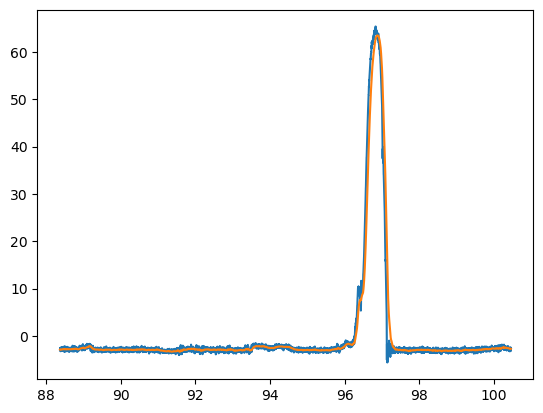

In [80]:
a, b = periods[3]
# for a, b in periods:
#     break
# ga = np.abs(gdat['time'] - cdat['time'][a]).argmin()
# gb = np.abs(gdat['time'] - cdat['time'][b]).argmin()
# plt.plot(gdat['time'][ga:gb], gdat['gripper_force'][ga:gb])

ra = np.abs(rdat['time'] - cdat['time'][a]).argmin()
rb = np.abs(rdat['time'] - cdat['time'][b]).argmin()
# ra, rb = 45454, 46500

# print(ra, rb)

smoothed = ewma(rdat['actual_force'][:,2], alpha=.04)
plt.plot(rdat['time'][ra:rb], rdat['actual_force'][ra:rb, 2])
plt.plot(rdat['time'][ra:rb], smoothed[ra:rb])


In [75]:
rdat['time'][rb] - rdat['time'][ra]

np.float64(2.1299984455108643)

In [58]:
ra, rb

(np.int64(43584), np.int64(49544))

In [7]:
rdat.keys()

dict_keys(['actual_force', 'actual_pose', 'time'])

In [5]:
import cv2
from ipywidgets import IntSlider, Output, HBox, VBox
from IPython.display import display, Image

images = cdat['image_bgr']

slider = IntSlider(min=0, max=len(images)-1, step=1, value=0,
                   continuous_update=True, description='Frame',
                   layout={'width': '600px'})
out = Output()

def show_frame(frame_idx):
    _, png = cv2.imencode('.jpg', images[frame_idx], [cv2.IMWRITE_JPEG_QUALITY, 90])
    out.clear_output(wait=True)
    with out:
        display(Image(data=png.tobytes(), width=600))

show_frame(0)
slider.observe(lambda change: show_frame(change['new']), names='value')
display(VBox([slider, out]))

In [6]:
periods = [
    [823, 1300],
    [1450, 2000],
    [2100, 2600],
    [2640, 3000],
    [3050, 3400]
]

In [16]:
1 / ((gdat['time'][1] - gdat['time'][0]))

239.44191356967517

In [22]:
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

smoothed = ewma(rdat['actual_force'][:, 2], alpha=.04)
dt = 5
delt_r = int(dt * 500) # Nominal 500Hz
delt_g = int(dt * 250) # Nominal 250Hz
cam_dt_ms = 1000 * np.median(np.diff(cdat['time']))

pi = 4
a, b = periods[pi]
frames = list(range(a, b))

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1.2], hspace=0.4)

ax_img = fig.add_subplot(gs[:, 0])
ax1    = fig.add_subplot(gs[0, 1])
ax2    = fig.add_subplot(gs[1, 1])
ax3    = fig.add_subplot(gs[2, 1])

ax_img.set_aspect('equal')
ax_img.axis('off')

# Initial frame
i0 = frames[0]
t0 = cdat['time'][i0]
ri0 = np.abs(rdat['time'] - t0).argmin()
gi0 = np.abs(gdat['time'] - t0).argmin()

img_artist = ax_img.imshow(cdat['image_bgr'][i0][:, :, ::-1])
ax_img.set_title(f'Trial {pi + 1}')

line_fraw, = ax1.plot(rdat['time'][ri0-delt_r:ri0], rdat['actual_force'][ri0-delt_r:ri0, 2])
line_fsmooth, = ax1.plot(rdat['time'][ri0-delt_r:ri0], smoothed[ri0-delt_r:ri0])
ax1.legend(['eef force', 'smoothed'], loc=1)

line_gf, = ax2.plot(gdat['time'][gi0-delt_g:gi0], gdat['gripper_force'][gi0-delt_g:gi0], 'C2')
ax2.legend(['gripper force'], loc=1)

line_gw, = ax3.plot(gdat['time'][gi0-delt_g:gi0], gdat['gripper_width'][gi0-delt_g:gi0], 'C2')
ax3.legend(['gripper width'], loc=1)

plt.close(fig)

def make_update(frames, img_artist, line_fraw, line_fsmooth, line_gf, line_gw, ax1, ax2, ax3):
    def update(frame_idx):
        i = frames[frame_idx]
        t = cdat['time'][i]
        ri = np.abs(rdat['time'] - t).argmin()
        gi = np.abs(gdat['time'] - t).argmin()

        img_artist.set_data(cdat['image_bgr'][i][:, :, ::-1])

        r_sl = slice(max(0, ri - delt_r), ri)
        line_fraw.set_data(rdat['time'][r_sl], rdat['actual_force'][r_sl, 2])
        line_fsmooth.set_data(rdat['time'][r_sl], smoothed[r_sl])
        ax1.set_xlim(rdat['time'][r_sl.start], rdat['time'][max(r_sl.stop - 1, r_sl.start)])
        ax1.relim(); ax1.autoscale_view(scalex=False)

        g_sl = slice(max(0, gi - delt_g), gi)
        line_gf.set_data(gdat['time'][g_sl], gdat['gripper_force'][g_sl])
        ax2.set_xlim(gdat['time'][g_sl.start], gdat['time'][max(g_sl.stop - 1, g_sl.start)])
        ax2.relim(); ax2.autoscale_view(scalex=False)

        line_gw.set_data(gdat['time'][g_sl], gdat['gripper_width'][g_sl])
        ax3.set_xlim(gdat['time'][g_sl.start], gdat['time'][max(g_sl.stop - 1, g_sl.start)])
        ax3.relim(); ax3.autoscale_view(scalex=False)

        return img_artist, line_fraw, line_fsmooth, line_gf, line_gw
    return update

update = make_update(frames, img_artist, line_fraw, line_fsmooth, line_gf, line_gw, ax1, ax2, ax3)

anim = FuncAnimation(fig, update, frames=len(frames),
                        interval=cam_dt_ms, blit=True)
# display(HTML(anim.to_html5_video()))
anim.save(f'period{pi+1}.mp4', fps=30)